# Notebook 8: Modelo de riesgo de severidad — comuna × año

Clasifica cada comuna-año en una de 4 categorías de riesgo de severidad de incendios
(**bajo / normal / alto / catastrófico**), prediciendo **solo desde variables climáticas**
(temperatura, precipitación, anomalías, estrés hídrico) — sin usar el propio conteo de
incendios o superficie quemada como feature, porque eso sería predecir el target con el
target (fuga de datos).

**Por qué clasificación y no regresión de hectáreas:** más fácil de explicar en la
presentación, y evita el problema de MAPE inflado / extrapolación fuera de rango que tuvo
la v1 de mtys (ver notebook 05).

**Entrada:** la tabla comuna × año que generó Spark (`04_agregacion_spark_comuna_anio.ipynb`).

**Definición del target:** cuartiles de `superficie_total_ha`, calculados **solo sobre el
conjunto de entrenamiento** (no sobre todo el dataset, para no filtrar información del test
hacia la definición de las categorías) — bajo (Q1), normal (Q2), alto (Q3), catastrófico (Q4).


## 1. Montar Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Instalar librerías

In [2]:
!pip install -q xgboost scikit-learn
print('✓ Librerías instaladas')


✓ Librerías instaladas


## 3. Configuración — EDITA la ruta antes de correr

In [3]:
import os, glob

# ⚠️ Debe ser la MISMA carpeta base usada en los notebooks anteriores
DRIVE_BASE = '/content/drive/MyDrive/BigDataSIC'

SPARK_OUTPUT_DIR = f'{DRIVE_BASE}/datos_procesados/spark_comuna_anio'
OUTPUT_DIR = f'{DRIVE_BASE}/datos_procesados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Entrada Spark :', SPARK_OUTPUT_DIR)


Entrada Spark : /content/drive/MyDrive/BigDataSIC/datos_procesados/spark_comuna_anio


## 4. Cargar la tabla comuna × año generada por Spark

In [4]:
import pandas as pd
import numpy as np

csv_matches = glob.glob(f'{SPARK_OUTPUT_DIR}/csv/part-*.csv')
assert csv_matches, f'No se encontró ningún part-*.csv en {SPARK_OUTPUT_DIR}/csv — ¿corriste el notebook 04?'

agg = pd.read_csv(csv_matches[0])
print(f'✓ {agg.shape[0]} filas comuna-año cargadas · años: {agg.año.min()}-{agg.año.max()}')
agg.head()


✓ 2617 filas comuna-año cargadas · años: 2010-2019


,region,comuna,año,n_incendios,superficie_total_ha,superficie_media_ha,superficie_max_ha,n_catastroficos,t2m_medio,tp_medio,t2m_anomaly_medio,tp_anomaly_medio,n_incendios_temporada_alta,t2m_anomaly_z,tp_anomaly_z,estres_hidrico_score,ranking_severidad_anio
0,Metropolitana,San Pedro,2010,29,5328.61,183.745172,3500.0,3,18.923760,0.003280,-0.326669,-3.197486,28,-0.799396,0.090283,-0.889679,1
1,Biobío,Coihueco,2010,24,3536.21,147.342083,3231.6,2,16.947250,0.158115,-0.485209,-22.333938,19,-1.047920,-0.680348,-0.367572,2
2,O'Higgins,Pichidegua,2010,6,3291.82,548.636667,2889.7,2,20.123702,0.005995,-0.522207,-3.950832,5,-1.105918,0.059945,-1.165864,3
3,Valparaíso,La Ligua,2010,41,3113.50,75.939024,3047.0,1,17.457074,0.008448,-0.527654,-2.227852,38,-1.114457,0.129330,-1.243787,4
4,Valparaíso,Cartagena,2010,26,2675.91,102.919615,2642.4,1,15.567278,0.053855,-0.617773,-3.924241,23,-1.255726,0.061016,-1.316742,5


## 5. Features — codificar región

Se agrega la región como variable categórica (one-hot) sobre TODO el dataset antes de
partir train/test, para que ambos conjuntos usen exactamente las mismas columnas.


In [5]:
FEATURES_CLIMA = [
    'año', 't2m_medio', 'tp_medio', 't2m_anomaly_medio', 'tp_anomaly_medio',
    't2m_anomaly_z', 'tp_anomaly_z', 'estres_hidrico_score',
]

region_dummies = pd.get_dummies(agg['region'], prefix='region')
agg_model = pd.concat([agg, region_dummies], axis=1)

FEATURES = FEATURES_CLIMA + list(region_dummies.columns)
print(f'✓ {len(FEATURES)} features · {len(region_dummies.columns)} regiones codificadas')


✓ 24 features · 16 regiones codificadas


## 6. Split temporal + definir el target sobre el train

Split temporal (no aleatorio): entrena con años tempranos, evalúa en los últimos — igual
criterio que los notebooks anteriores, para simular predicción real hacia el futuro, no
interpolación dentro del mismo período.


In [6]:
ANIO_CORTE = agg_model['año'].quantile(0.7)  # ~70% train / 30% test por tiempo
train = agg_model[agg_model['año'] <= ANIO_CORTE].copy()
test  = agg_model[agg_model['año'] >  ANIO_CORTE].copy()

print(f'Corte temporal: año <= {ANIO_CORTE:.0f} = train, año > {ANIO_CORTE:.0f} = test')
print(f'Train: {len(train)} filas ({train.año.min()}-{train.año.max()})')
print(f'Test : {len(test)} filas ({test.año.min()}-{test.año.max()})')

q1, q2, q3 = train['superficie_total_ha'].quantile([0.25, 0.5, 0.75])
print(f'\nUmbrales de severidad (calculados SOLO en train): Q1={q1:.2f} ha, Q2={q2:.2f} ha, Q3={q3:.2f} ha')

def categorizar(superficie):
    if superficie <= q1:
        return 'bajo'
    elif superficie <= q2:
        return 'normal'
    elif superficie <= q3:
        return 'alto'
    else:
        return 'catastrofico'

train['riesgo'] = train['superficie_total_ha'].apply(categorizar)
test['riesgo']  = test['superficie_total_ha'].apply(categorizar)

print('\nDistribución en train:')
print(train['riesgo'].value_counts())
print('\nDistribución en test (con los MISMOS umbrales de train — puede no ser 25/25/25/25):')
print(test['riesgo'].value_counts())


Corte temporal: año <= 2017 = train, año > 2017 = test
Train: 2039 filas (2010-2017)
Test : 578 filas (2018-2019)

Umbrales de severidad (calculados SOLO en train): Q1=7.00 ha, Q2=34.13 ha, Q3=152.66 ha

Distribución en train:
riesgo
bajo            514
catastrofico    510
alto            509
normal          506
Name: count, dtype: int64

Distribución en test (con los MISMOS umbrales de train — puede no ser 25/25/25/25):
riesgo
bajo            161
alto            148
normal          142
catastrofico    127
Name: count, dtype: int64


## 7. Entrenar el clasificador (XGBoost, 4 clases)

In [7]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

CLASES = ['bajo', 'normal', 'alto', 'catastrofico']
le = LabelEncoder()
le.fit(CLASES)

X_train, y_train = train[FEATURES], le.transform(train['riesgo'])
X_test,  y_test  = test[FEATURES],  le.transform(test['riesgo'])

modelo = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=4,
    random_state=42, eval_metric='mlogloss',
)
modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)
print('✓ Modelo entrenado')


✓ Modelo entrenado


## 8. Evaluación — métricas honestas por clase

No solo accuracy global (puede verse bien aunque el modelo solo acierte la clase mayoritaria)
— se reporta precision/recall/F1 por cada categoría de riesgo.


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f'Accuracy global: {accuracy_score(y_test, pred):.3f}')
print()
print('Reporte por clase:')
print(classification_report(y_test, pred, target_names=CLASES, zero_division=0))

print('Matriz de confusión (filas=real, columnas=predicho):')
cm = confusion_matrix(y_test, pred, labels=range(4))
print(pd.DataFrame(cm, index=CLASES, columns=CLASES))


Accuracy global: 0.362

Reporte por clase:
              precision    recall  f1-score   support

        bajo       0.26      0.23      0.24       148
      normal       0.48      0.61      0.54       161
        alto       0.33      0.31      0.32       127
catastrofico       0.31      0.25      0.28       142

    accuracy                           0.36       578
   macro avg       0.34      0.35      0.35       578
weighted avg       0.35      0.36      0.35       578

Matriz de confusión (filas=real, columnas=predicho):
              bajo  normal  alto  catastrofico
bajo            34      39    37            38
normal          29      99    14            19
alto            36      26    40            25
catastrofico    33      44    29            36


## 9. Importancia de variables

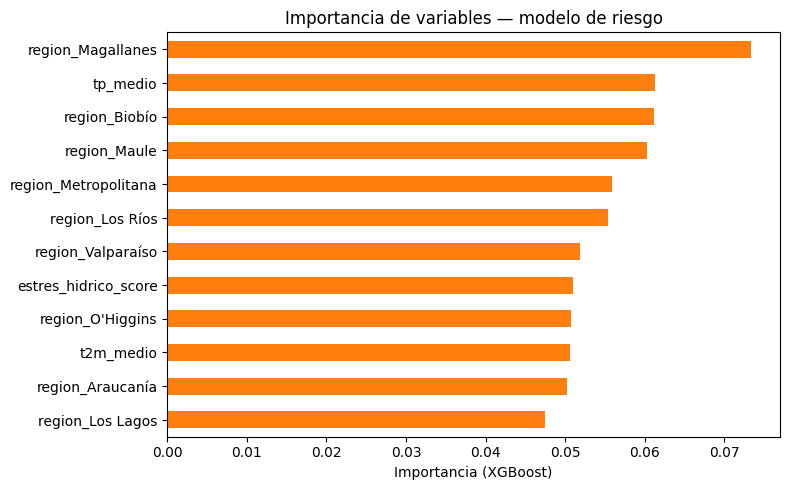

region_Magallanes       0.073
tp_medio                0.061
region_Biobío           0.061
region_Maule            0.060
region_Metropolitana    0.056
region_Los Ríos         0.055
region_Valparaíso       0.052
estres_hidrico_score    0.051
region_O'Higgins        0.051
t2m_medio               0.051
region_Araucanía        0.050
region_Los Lagos        0.047
dtype: float32


In [9]:
import matplotlib.pyplot as plt

importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.sort_values().plot.barh(ax=ax, color='tab:orange')
ax.set_title('Importancia de variables — modelo de riesgo')
ax.set_xlabel('Importancia (XGBoost)')
plt.tight_layout()
plt.show()

print(importancias.round(3))


## 10. Tabla de riesgo por comuna (año más reciente del test)

Ranking práctico: qué comunas quedaron clasificadas en mayor riesgo en el último año
disponible — útil para el dashboard y para la presentación.


In [10]:
test_out = test.copy()
test_out['riesgo_predicho'] = le.inverse_transform(pred)
test_out['prob_catastrofico'] = modelo.predict_proba(X_test)[:, le.transform(['catastrofico'])[0]]

ultimo_anio = test_out['año'].max()
print(f'Comunas de mayor riesgo predicho — {int(ultimo_anio)}:')
(
    test_out[test_out['año'] == ultimo_anio]
    .sort_values('prob_catastrofico', ascending=False)
    [['region', 'comuna', 'riesgo', 'riesgo_predicho', 'prob_catastrofico']]
    .head(15)
)


Comunas de mayor riesgo predicho — 2019:


,region,comuna,riesgo,riesgo_predicho,prob_catastrofico
2336,Metropolitana,Lampa,catastrofico,catastrofico,0.750186
2437,Valparaíso,Olmué,alto,catastrofico,0.720735
2597,Maule,Licantén,bajo,catastrofico,0.710264
2448,Maule,Yerbas Buenas,alto,catastrofico,0.708499
2390,O'Higgins,Las Cabras,catastrofico,catastrofico,0.698335
2467,O'Higgins,Pumanque,normal,catastrofico,0.697180
2428,O'Higgins,San Vicente,alto,catastrofico,0.689940
2354,Maule,Rauco,catastrofico,catastrofico,0.681304
2409,Araucanía,Padre Las Casas,alto,catastrofico,0.669425
2424,Metropolitana,Paine,alto,catastrofico,0.667346


## 11. Guardar resultados

In [11]:
out_csv = f'{OUTPUT_DIR}/modelo_riesgo_comuna_anio.csv'
test_out.to_csv(out_csv, index=False)

print(f'✓ Guardado: {out_csv}')
print(f'  {len(test_out)} filas (años {test_out.año.min()}-{test_out.año.max()}) con riesgo real vs predicho')


✓ Guardado: /content/drive/MyDrive/BigDataSIC/datos_procesados/modelo_riesgo_comuna_anio.csv
  578 filas (años 2018-2019) con riesgo real vs predicho


## ✅ Checklist de validación

- [x] El target (`riesgo`) se define con umbrales calculados SOLO en train, no en todo el
      dataset — evita fuga de información del futuro hacia la definición de categorías.
- [x] Las features son climáticas puras — no se usa `n_incendios`/`superficie_*` como
      predictor (evita predecir el target con el target).
- [x] Métricas por clase, no solo accuracy global — se ve explícitamente si el modelo solo
      acierta la clase mayoritaria o realmente distingue las 4 categorías.
- [x] Split temporal (no aleatorio) — simula predicción hacia años futuros, no interpolación.

**Nota honesta para la presentación:** con ~10 años de datos agregados por comuna, el
tamaño de muestra es modesto — las métricas de este modelo deben presentarse como una
prueba de concepto (el estrés hídrico climático sí correlaciona con severidad, dirección
correcta), no como un sistema de predicción listo para producción.
